In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [4]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [5]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0
...,...,...,...,...,...
395,15691863,0,46,41000,1
396,15706071,1,51,23000,1
397,15654296,0,50,20000,1
398,15755018,1,36,33000,0


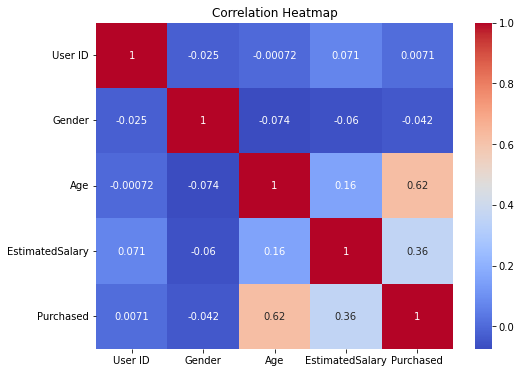

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

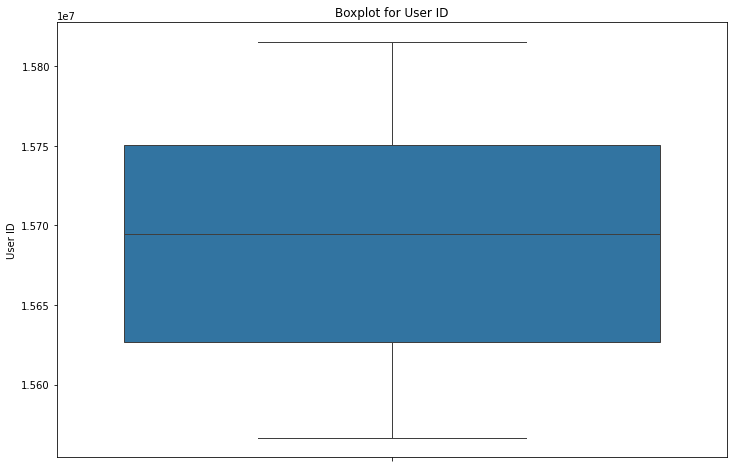

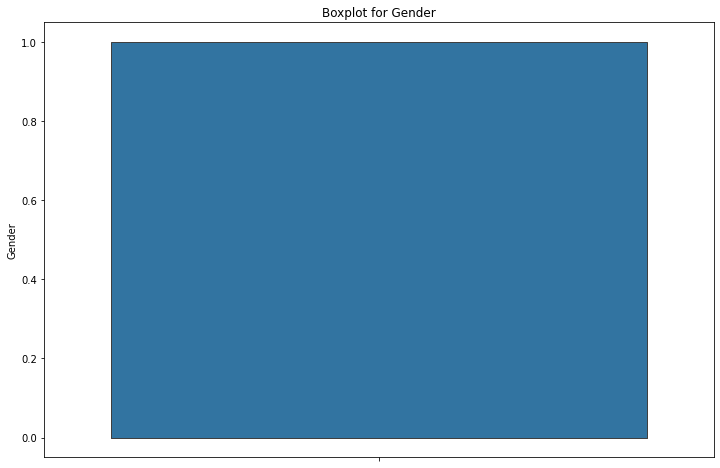

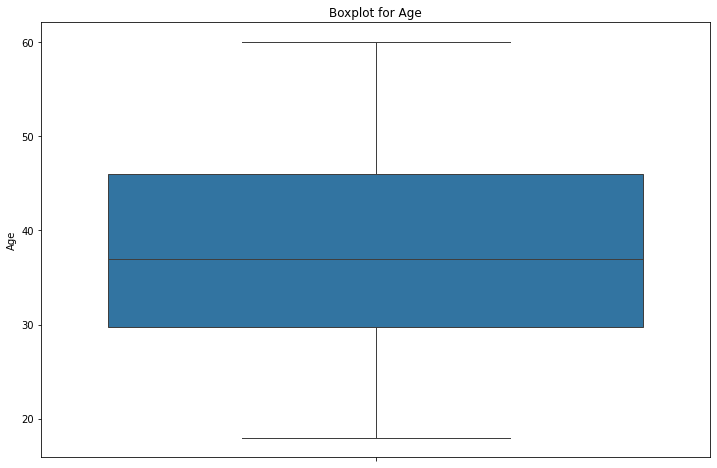

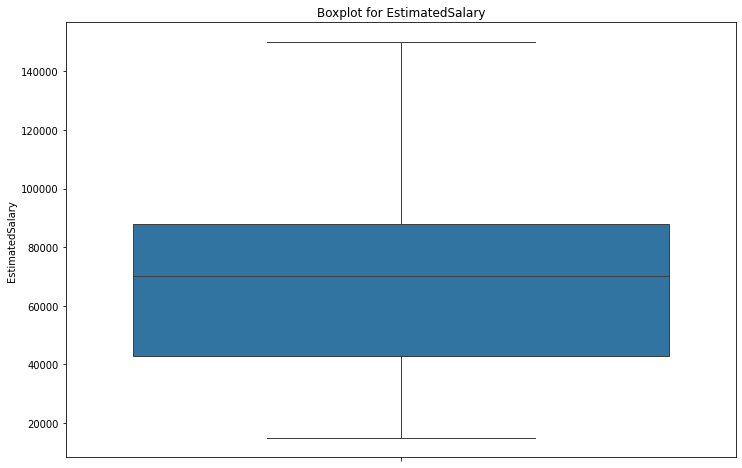

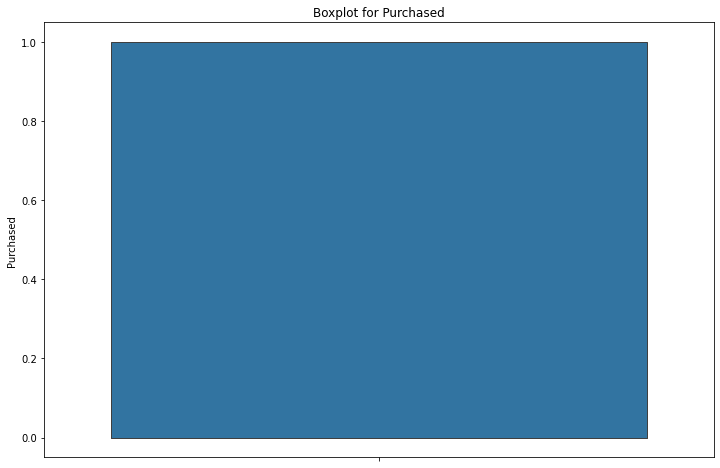

In [7]:
for column in df.columns:
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df[column])
    plt.title(f"Boxplot for {column}")
    plt.show()

In [8]:
X = df[['Age', 'EstimatedSalary']] 
y = df['Purchased']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [10]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### With sklearn

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[65  3]
 [ 8 24]]


In [14]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

accuracy = (TP + TN) / (TP + TN + FP + FN)
err_rate = (FP + FN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * ((precision * recall) / (precision + recall))

print("Accuracy:", accuracy)
print("Error Rate:", err_rate)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Accuracy: 0.89
Error Rate: 0.11
Precision: 0.8888888888888888
Recall: 0.75
F1 Score: 0.8135593220338982


### Without sklearn

In [15]:
import numpy as np
import pandas as pd

In [17]:
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

In [18]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [19]:
m, n = X.shape

weights = np.zeros(n)
bias = 0

learning_rate = 0.01
epochs = 1000

In [20]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [21]:
for i in range(epochs):
    z = np.dot(X, weights) + bias
    y_pred = sigmoid(z)

    # Compute gradients
    dw = (1/m) * np.dot(X.T, (y_pred - y))
    db = (1/m) * np.sum(y_pred - y)

    # Update parameters
    weights -= learning_rate * dw
    bias -= learning_rate * db

In [22]:
z = np.dot(X, weights) + bias
y_pred_prob = sigmoid(z)

# Convert probabilities to 0/1
y_pred = [1 if i >= 0.5 else 0 for i in y_pred_prob]

In [23]:
TP = FP = TN = FN = 0

for i in range(len(y)):
    if y[i] == 1 and y_pred[i] == 1:
        TP += 1
    elif y[i] == 0 and y_pred[i] == 0:
        TN += 1
    elif y[i] == 0 and y_pred[i] == 1:
        FP += 1
    elif y[i] == 1 and y_pred[i] == 0:
        FN += 1

print("Confusion Matrix:")
print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

Confusion Matrix:
TP: 99
TN: 238
FP: 19
FN: 44


In [25]:
accuracy = (TP + TN) / len(y)
error_rate = (FP + FN) / len(y)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_score = 2 * ((precision * recall) / (precision + recall))

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Accuracy: 0.8425
Error Rate: 0.1575
Precision: 0.8389830508474576
Recall: 0.6923076923076923
F1 Score: 0.7586206896551724
